# EDA — TRAIN-ONLY (Step 8, Khung A)

**Bài toán**: dự đoán hướng biến động tích lũy giá TCB (HOSE), $k\in\{1,5,10,20\}$.

Notebook chạy **chỉ trên slice train** (80% cũ nhất, lấy từ `src/model/split.py`).
Vai trò: **train ĐỀ XUẤT** quyết định feature (keep/drop/transform) + chốt bộ `eda`.
Val sẽ CHỌN (Step 10), test PHÁN (Step 12) — không đụng ở đây.

Quy ước: ranh giới split k-độc lập (train|val @ idx 1394); phân tích feature↔nhãn
từng $k$ dùng `train_idx` đã embargo của horizon đó (nhãn quan sát được, không rỉ).

> Tiêu chí chọn model ở Step 10 đã KHÓA = **MCC / balanced-acc** (không dùng accuracy
> thô) vì val là một regime tăng mạnh (pct_pos k=20 ≈ 83%) còn test đi ngang/giảm
> (≈ 43%) → accuracy thô trên val đánh lừa. EDA train-only không bị ảnh hưởng vì
> train ổn định (pct_pos 55–58% mọi k).

**Xuất**: `config/feature_sets.json` (`l1`/`eda`/`full`) + `reports/eda/feature_decision.csv` + figures.

In [1]:
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf
from sklearn.feature_selection import mutual_info_classif
from lightgbm import LGBMClassifier

import sys
ROOT = Path.cwd()
# Cho phép chạy notebook từ thư mục notebook/ hoặc root repo
if (ROOT / "src").exists():
    REPO = ROOT
elif (ROOT.parent / "src").exists():
    REPO = ROOT.parent
else:
    raise RuntimeError("Không tìm thấy repo root (thiếu thư mục src/)")
sys.path.insert(0, str(REPO))

from src.model import split as S

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

FEATURES_PATH = REPO / "data" / "processed" / "features.parquet"
FIG = REPO / "reports" / "eda" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
OUT_DECISION = REPO / "reports" / "eda" / "feature_decision.csv"
OUT_SETS = REPO / "config" / "feature_sets.json"
OUT_SETS.parent.mkdir(parents=True, exist_ok=True)

# 4 lớp feature (khớp src/data/features.py)
L1 = ["r1", "r5", "r10", "r20"]
L2 = ["ma5_20", "momentum_3_12", "bb_position", "trb", "rsi_14", "macd_norm"]
L3 = ["vnindex_ret", "fx_logchg", "cpi_yoy", "gdp_yoy"]
L4 = ["total_assets_yoy", "pe_ratio", "npl_ratio", "credit_yoy", "nim", "equity_to_assets"]
LAYER = {f: lyr for lyr, fs in [("L1", L1), ("L2", L2), ("L3", L3), ("L4", L4)] for f in fs}
HORIZONS = S.HORIZONS

df = pd.read_parquet(FEATURES_PATH)
df["date"] = pd.to_datetime(df["date"])
FEATS = S.feature_columns(df)
assert FEATS == L1 + L2 + L3 + L4, "Tên/thứ tự feature lệch src/data/features.py"

# Slice train (k-độc lập cho phân tích feature; dùng train của k=1 làm vùng train chung)
sp1 = S.make_split(df["date"], 1)
TR = df.iloc[sp1.train_idx[0]: sp1.train_end].reset_index(drop=True)   # [0, 1394)
print(f"Toàn bộ: {len(df)} phiên | train (EDA) = {len(TR)} phiên "
      f"[{TR['date'].iloc[0].date()} .. {TR['date'].iloc[-1].date()}]")

Toàn bộ: 1742 phiên | train (EDA) = 1394 phiên [2019-06-07 .. 2024-12-26]


## 1. Chất lượng & class balance (train)

Missing / dtype / mô tả nhanh; tỉ lệ lớp `pct_pos` từng $k$ trên train (kỳ vọng ổn định 55–58%).

In [2]:
print("dtype & missing (train):")
qual = pd.DataFrame({
    "dtype": TR[FEATS].dtypes.astype(str),
    "n_missing": TR[FEATS].isna().sum(),
    "n_unique": TR[FEATS].nunique(),
})
print(qual)

print("\nclass balance train (pct_pos = % nhãn +1):")
for k in HORIZONS:
    tr_idx = S.make_split(df["date"], k).train_idx
    yk = df[f"y_{k}"].iloc[tr_idx]
    print(f"  k={k:<2d}  n={yk.notna().sum():<5d}  pct_pos={100*float((yk==1).mean()):.2f}%")

dtype & missing (train):
                    dtype  n_missing  n_unique
r1                float64          0      1219
r5                float64          0      1336
r10               float64          0      1343
r20               float64          0      1362
ma5_20            float64          0      1393
momentum_3_12     float64          0      1364
bb_position       float64          0      1393
trb               float64          0         3
rsi_14            float64          0      1301
macd_norm         float64          0      1394
vnindex_ret       float64          0      1394
fx_logchg         float64          0       906
cpi_yoy           float64          0        67
gdp_yoy           float64          0        23
total_assets_yoy  float64          0        23
pe_ratio          float64          0        22
npl_ratio         float64          0        21
credit_yoy        float64          0        23
nim               float64          0        21
equity_to_assets  float64          

## 2. Đơn biến — phân phối + ADF stationarity

- **Fat tail**: skew/kurtosis (return đuôi béo → lý do dự đoán *hướng* chứ không *biên độ*).
- **ADF** (Dickey-Fuller): H0 = có unit root (non-stationary). Feature dùng cho model nên stationary.

                 layer     mean      std    skew  kurtosis   adf_p  stationary@5%
feature                                                                          
r1                  L1   0.0006   0.0209 -0.3676    2.6514  0.0000           True
r5                  L1   0.0029   0.0496 -0.2397    2.8155  0.0000           True
r10                 L1   0.0057   0.0715 -0.3003    2.1632  0.0000           True
r20                 L1   0.0110   0.1029 -0.7625    3.2111  0.0001           True
ma5_20              L2   1.0045   0.0443 -0.4426    2.3306  0.0000           True
momentum_3_12       L2   0.0631   0.3885  0.3510   -0.3585  0.4292          False
bb_position         L2   0.0941   0.6593 -0.1614   -0.7284  0.0000           True
trb                 L2   0.0495   0.4528  0.2046    1.7890  0.0000           True
rsi_14              L2  52.5129  13.6157 -0.2194    0.2345  0.0000           True
macd_norm           L2   0.0015   0.0292 -1.5120    4.6741  0.0000           True
vnindex_ret     

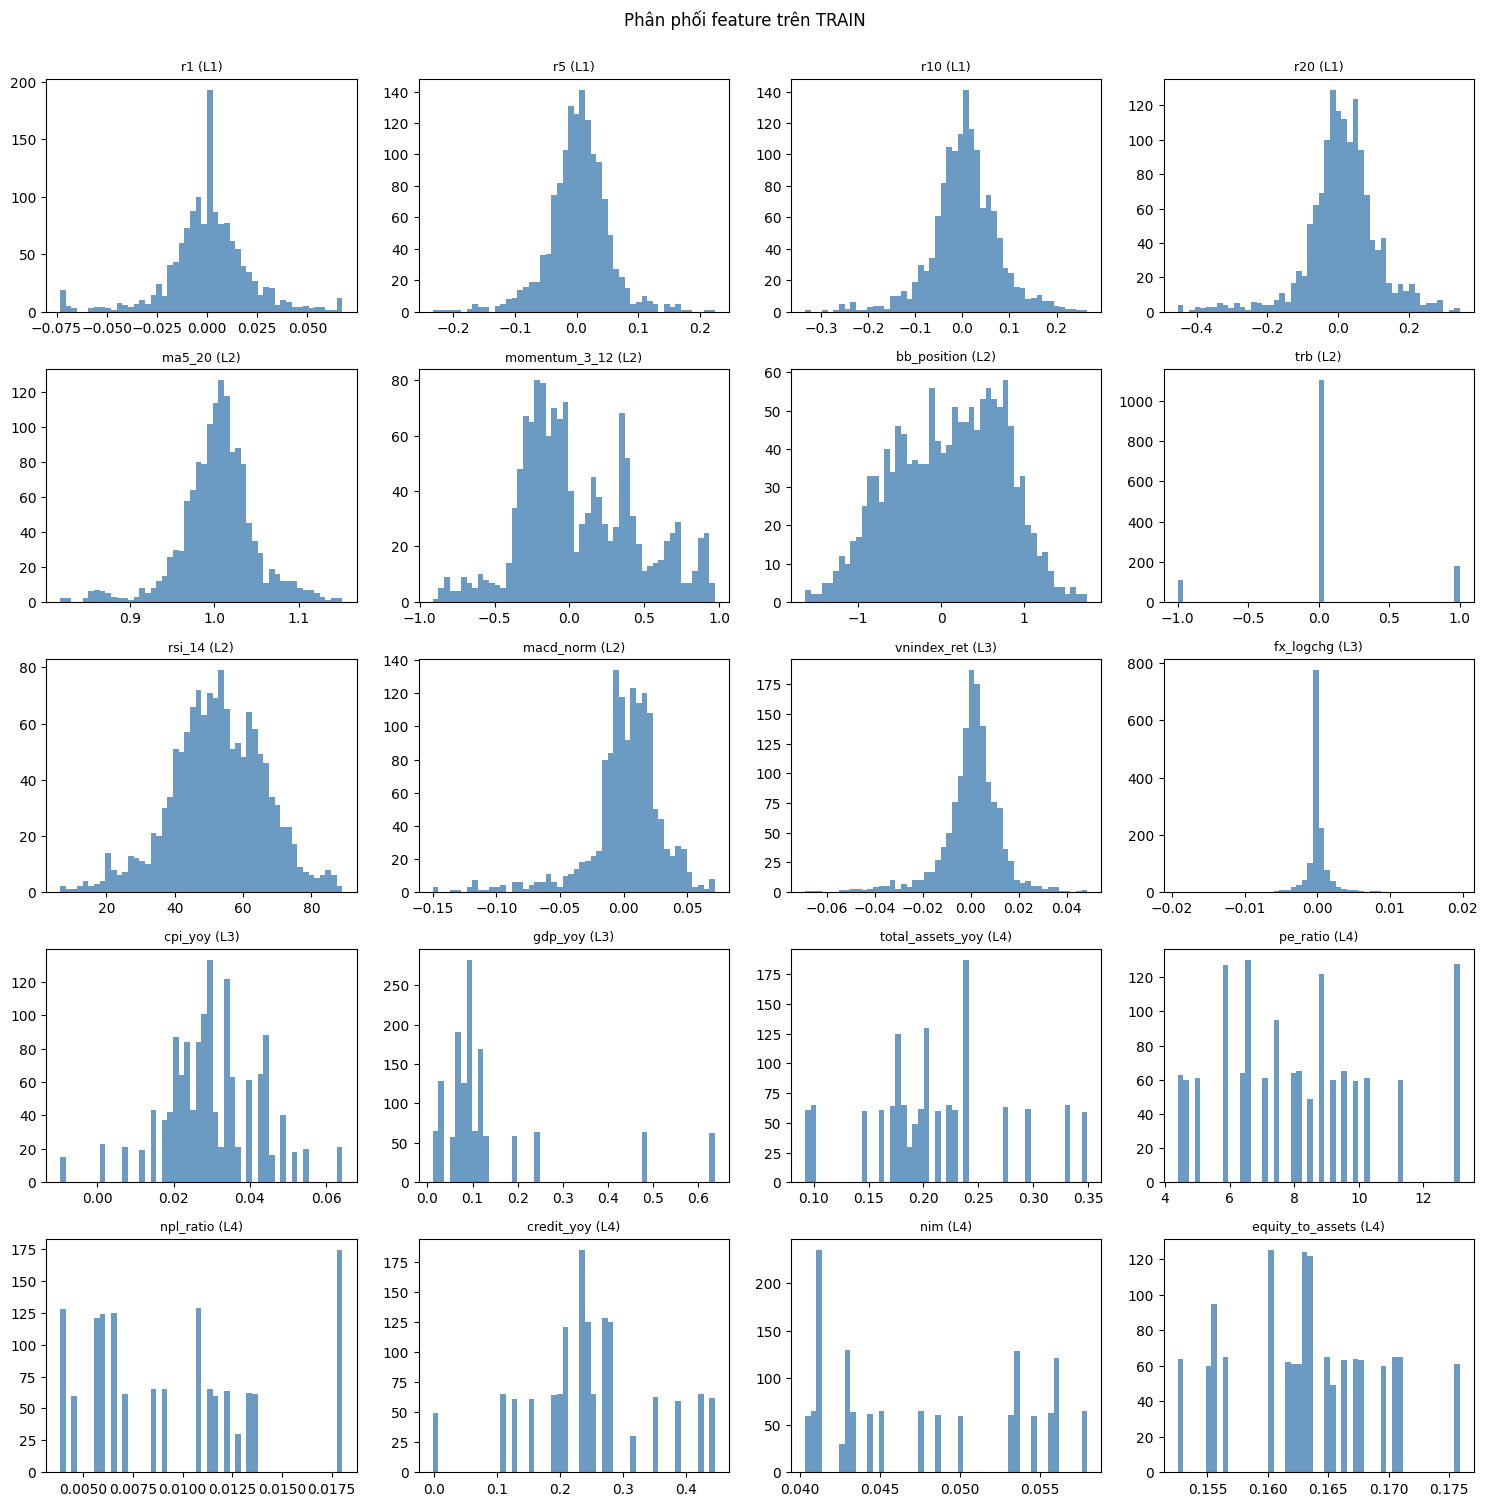

In [3]:
rows = []
for f in FEATS:
    x = TR[f].dropna()
    try:
        adf_p = adfuller(x, autolag="AIC")[1]
    except Exception:
        adf_p = np.nan
    rows.append({
        "feature": f, "layer": LAYER[f],
        "mean": x.mean(), "std": x.std(),
        "skew": x.skew(), "kurtosis": x.kurtosis(),
        "adf_p": adf_p, "stationary@5%": adf_p < 0.05 if np.isfinite(adf_p) else None,
    })
uni = pd.DataFrame(rows).set_index("feature")
print(uni.round(4))

# Lưới histogram
ncol = 4; nrow = int(np.ceil(len(FEATS) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(15, 3 * nrow))
for i, f in enumerate(FEATS):
    a = ax.flat[i]
    a.hist(TR[f].dropna(), bins=50, color="steelblue", alpha=0.8)
    a.set_title(f"{f} ({LAYER[f]})", fontsize=9)
for j in range(len(FEATS), nrow * ncol):
    ax.flat[j].axis("off")
fig.suptitle("Phân phối feature trên TRAIN", y=1.001); fig.tight_layout()
fig.savefig(FIG / "01_feature_hist.png", dpi=110, bbox_inches="tight"); plt.show()

## 3. Cấu trúc thời gian — ACF return vs ACF return²

Kỳ vọng (weak-form EMH): ACF của return $\approx 0$ (hướng khó dự đoán từ chính nó),
nhưng ACF của return² $>0$ (volatility clustering). Bối cảnh cho độ khó của bài toán.

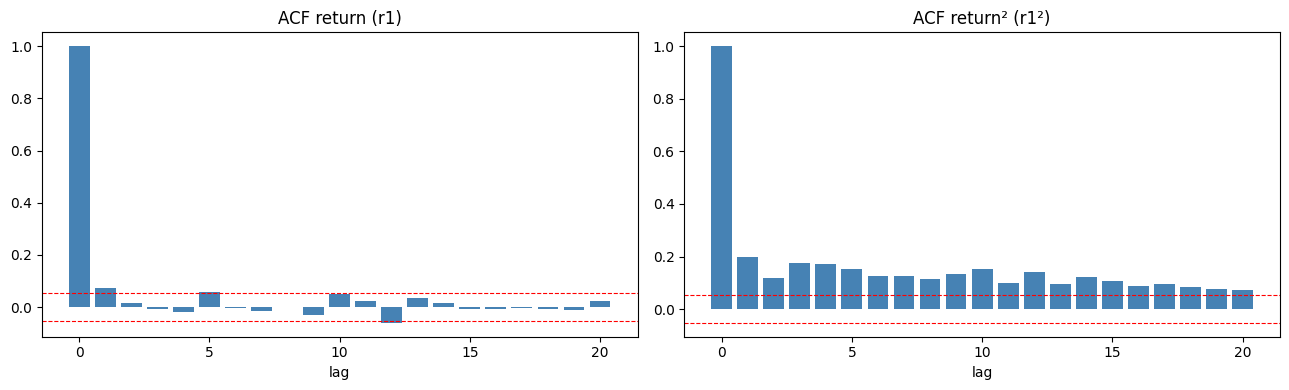

ACF r1   lag1..5: [ 0.075  0.015 -0.009 -0.019  0.056]  (conf ±0.052)
ACF r1²  lag1..5: [0.2   0.117 0.177 0.17  0.151]  -> clustering nếu > conf


In [4]:
r = TR["r1"].dropna().to_numpy()
nlags = 20
acf_r = acf(r, nlags=nlags, fft=True)
acf_r2 = acf(r**2, nlags=nlags, fft=True)
conf = 1.96 / np.sqrt(len(r))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, vals, ttl in [(ax[0], acf_r, "ACF return (r1)"),
                     (ax[1], acf_r2, "ACF return² (r1²)")]:
    a.bar(range(nlags + 1), vals, color="steelblue")
    a.axhline(conf, ls="--", c="r", lw=0.8); a.axhline(-conf, ls="--", c="r", lw=0.8)
    a.set_title(ttl); a.set_xlabel("lag")
fig.tight_layout(); fig.savefig(FIG / "02_acf.png", dpi=110); plt.show()
print(f"ACF r1   lag1..5: {np.round(acf_r[1:6], 3)}  (conf ±{conf:.3f})")
print(f"ACF r1²  lag1..5: {np.round(acf_r2[1:6], 3)}  -> clustering nếu > conf")

## 4. Đa biến — multicollinearity (quan trọng cho Elastic Net)

Heatmap tương quan + các cặp |corr| cao. Trong cụm cộng tuyến mạnh, ta sẽ bỏ bớt
feature dư thừa (giữ feature tín hiệu mạnh hơn) ở phần quyết định.

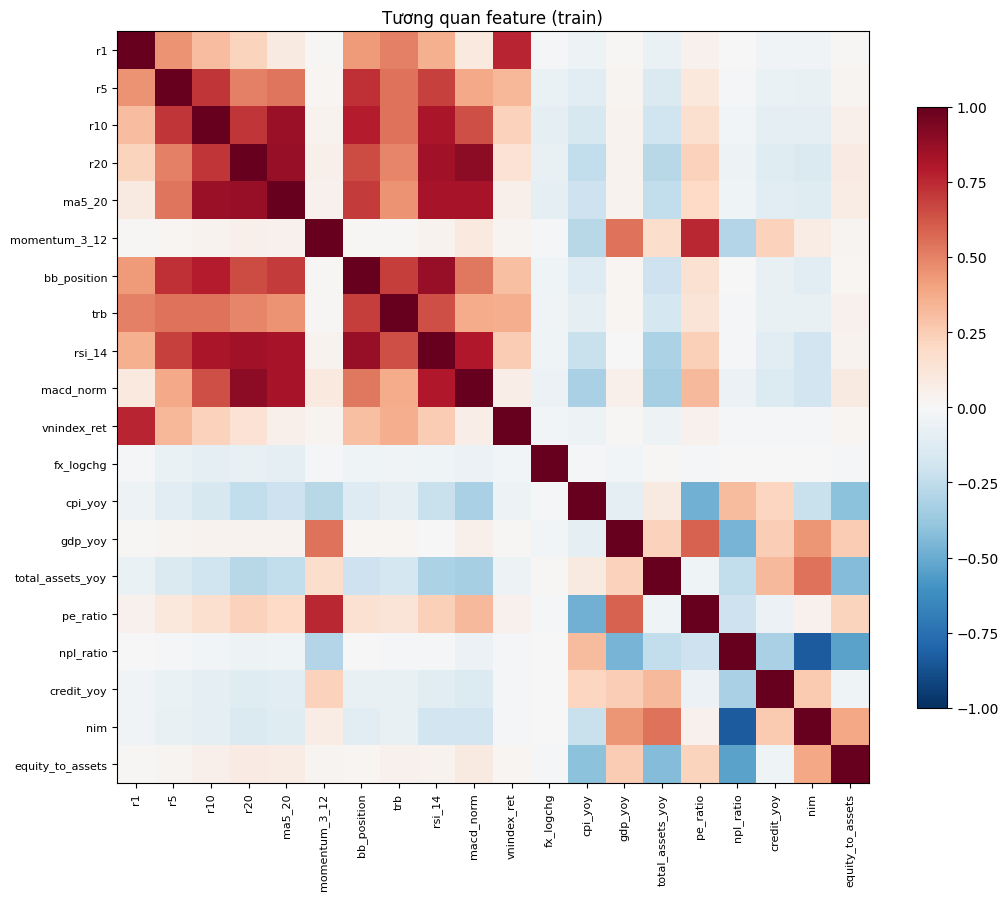

Cặp |corr| >= 0.85:
  r20                ~ macd_norm           corr=0.894
  bb_position        ~ rsi_14              corr=0.871
  r20                ~ ma5_20              corr=0.87
  r10                ~ ma5_20              corr=0.866


In [5]:
C = TR[FEATS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATS))); ax.set_xticklabels(FEATS, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATS))); ax.set_yticklabels(FEATS, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Tương quan feature (train)")
fig.tight_layout(); fig.savefig(FIG / "03_corr_heatmap.png", dpi=110); plt.show()

THRESH = 0.85
pairs = []
for i in range(len(FEATS)):
    for j in range(i + 1, len(FEATS)):
        c = C.iloc[i, j]
        if abs(c) >= THRESH:
            pairs.append((FEATS[i], FEATS[j], round(float(c), 3)))
print(f"Cặp |corr| >= {THRESH}:")
for p in sorted(pairs, key=lambda x: -abs(x[2])):
    print(f"  {p[0]:18s} ~ {p[1]:18s}  corr={p[2]}")
if not pairs:
    print("  (không có cặp nào vượt ngưỡng)")

## 4b. Tín hiệu feature → nhãn từng $k$ + LightGBM importance

- **|corr| point-biserial** giữa feature (liên tục) và nhãn {0,1}.
- **Mutual information** (`mutual_info_classif`) — bắt phi tuyến.
- **LightGBM gain importance** — train nhanh trên train từng $k$.

Tổng hợp thành `signal_score` chuẩn hoá [0,1] (trung bình 3 nguồn, bình quân qua $k$).

In [6]:
def per_k_signal(k):
    tr_idx = S.make_split(df["date"], k).train_idx
    X = df.iloc[tr_idx][FEATS].to_numpy(float)
    y = df.iloc[tr_idx][f"y_{k}"].to_numpy(float)
    m = ~np.isnan(y)
    X, y = X[m], (y[m] > 0).astype(int)
    # corr point-biserial
    corr = np.array([abs(np.corrcoef(X[:, i], y)[0, 1]) for i in range(X.shape[1])])
    # mutual info
    mi = mutual_info_classif(X, y, random_state=42)
    # lgb gain importance
    lgb = LGBMClassifier(n_estimators=200, num_leaves=31, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
    lgb.fit(X, y)
    imp = lgb.booster_.feature_importance(importance_type="gain").astype(float)
    return corr, np.nan_to_num(mi), imp

def norm01(v):
    v = np.asarray(v, float); rng = v.max() - v.min()
    return (v - v.min()) / rng if rng > 0 else np.zeros_like(v)

corr_k, mi_k, imp_k = {}, {}, {}
for k in HORIZONS:
    c, mi, imp = per_k_signal(k)
    corr_k[k], mi_k[k], imp_k[k] = c, mi, imp

# bảng |corr| từng k
corr_tbl = pd.DataFrame({f"corr_k{k}": corr_k[k] for k in HORIZONS}, index=FEATS)
print("|corr| feature↔nhãn từng k (train):")
print(corr_tbl.round(3))

# signal_score = trung bình (norm corr + norm mi + norm imp) qua các k
score = np.zeros(len(FEATS))
for k in HORIZONS:
    score += norm01(corr_k[k]) + norm01(mi_k[k]) + norm01(imp_k[k])
score /= (3 * len(HORIZONS))
signal = pd.Series(score, index=FEATS, name="signal_score").sort_values(ascending=False)
print("\nsignal_score (cao = tín hiệu mạnh hơn, chuẩn hoá [0,1]):")
print(signal.round(4))

|corr| feature↔nhãn từng k (train):
                  corr_k1  corr_k5  corr_k10  corr_k20
r1                  0.039    0.011     0.007     0.011
r5                  0.009    0.031     0.013     0.012
r10                 0.007    0.004     0.050     0.051
r20                 0.002    0.017     0.020     0.099
ma5_20              0.017    0.007     0.035     0.084
momentum_3_12       0.011    0.003     0.013     0.016
bb_position         0.003    0.025     0.058     0.032
trb                 0.057    0.010     0.003     0.002
rsi_14              0.005    0.026     0.006     0.079
macd_norm           0.004    0.025     0.011     0.064
vnindex_ret         0.009    0.059     0.025     0.010
fx_logchg           0.023    0.018     0.039     0.013
cpi_yoy             0.029    0.029     0.091     0.058
gdp_yoy             0.010    0.001     0.010     0.077
total_assets_yoy    0.055    0.134     0.153     0.208
pe_ratio            0.040    0.058     0.102     0.074
npl_ratio           0.011    

## 5. Quyết định keep/drop/transform + chốt bộ `eda`

Heuristic (minh bạch, **giả thuyết** — val sẽ xác nhận ở Step 10):
1. **Drop cộng tuyến**: trong mỗi cặp |corr| ≥ 0.85, bỏ feature `signal_score` thấp hơn.
2. **Drop tín hiệu yếu**: feature có `signal_score` < phân vị 25% (và không thuộc nhóm vừa giữ ở bước 1).
3. `eda` = 20 feature − (drop cộng tuyến ∪ drop yếu).

`l1` và `full` cố định. Ghi `config/feature_sets.json`. **Bạn có thể chỉnh tay bộ `eda`
trong file đó trước khi sang Step 10** nếu muốn ghi đè heuristic.

In [7]:
drop_collinear = set()
for a, b, c in pairs:
    lo = a if signal[a] <= signal[b] else b
    drop_collinear.add(lo)

q25 = signal.quantile(0.25)
drop_weak = set(signal[signal < q25].index) - drop_collinear

eda_set = [f for f in FEATS if f not in (drop_collinear | drop_weak)]

decision = pd.DataFrame(index=FEATS)
decision["layer"] = [LAYER[f] for f in FEATS]
decision["signal_score"] = signal.reindex(FEATS).round(4)
decision["drop_collinear"] = [f in drop_collinear for f in FEATS]
decision["drop_weak"] = [f in drop_weak for f in FEATS]
decision["in_eda"] = [f in eda_set for f in FEATS]
decision = decision.sort_values("signal_score", ascending=False)
print(decision)
decision.to_csv(OUT_DECISION)

feature_sets = {
    "l1": L1,
    "eda": eda_set,
    "full": FEATS,
    "_meta": {
        "source": "EDA train-only (Step 8)",
        "drop_collinear": sorted(drop_collinear),
        "drop_weak": sorted(drop_weak),
        "collinear_threshold": THRESH,
        "weak_quantile": 0.25,
        "note": "eda là GIẢ THUYẾT từ train; val chọn bộ thắng ở Step 10. Có thể chỉnh tay.",
    },
}
OUT_SETS.write_text(json.dumps(feature_sets, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"\n-> Ghi {OUT_SETS.relative_to(REPO)}")
print(f"   l1   ({len(L1)}): {L1}")
print(f"   eda  ({len(eda_set)}): {eda_set}")
print(f"   full ({len(FEATS)})")
print(f"   bỏ do cộng tuyến: {sorted(drop_collinear)}")
print(f"   bỏ do tín hiệu yếu: {sorted(drop_weak)}")

                 layer  signal_score  drop_collinear  drop_weak  in_eda
cpi_yoy             L3        0.6853           False      False    True
total_assets_yoy    L4        0.6358           False      False    True
macd_norm           L2        0.4323           False      False    True
momentum_3_12       L2        0.3921           False      False    True
pe_ratio            L4        0.3645           False      False    True
nim                 L4        0.3127           False      False    True
gdp_yoy             L3        0.3091           False      False    True
credit_yoy          L4        0.3071           False      False    True
ma5_20              L2        0.2789           False      False    True
r20                 L1        0.2716            True      False   False
rsi_14              L2        0.2707           False      False    True
r10                 L1        0.2670            True      False   False
r5                  L1        0.2494           False      False 